**Dependencies**

In [2]:
!kaggle --version

Kaggle CLI 2.0.2


In [3]:
# Install the one package not preinstalled on Kaggle/Colab
!pip install -q timm

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


**Dataset**

In [5]:

from google.colab import files
print("Upload your kaggle.json file:")
files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!pip install -q kaggle
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces -p /content/data --unzip

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:23<00:00, 168MB/s]



In [7]:
# Set the dataset path depending on where you're running this.
# Kaggle (default):
# DATA_DIR = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"

# Colab (uncomment this line instead, after running the download cell above):
DATA_DIR = "/content/data/real_vs_fake/real-vs-fake"

print("Contents of DATA_DIR:", os.listdir(DATA_DIR))
print("Contents of train/:", os.listdir(os.path.join(DATA_DIR, "train")))

Contents of DATA_DIR: ['test', 'train', 'valid']
Contents of train/: ['fake', 'real']


**Preprocessing and Data Loaders**


Standard face-classifier preprocessing: resize to 224x224, normalize with ImageNet stats, and mild augmentation on the training set only (flip + slight color jitter — nothing aggressive, since heavy blur/color changes can wash out the subtle artifacts that separate real from fake).

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
valid_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "valid"), transform=eval_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=eval_transform)

print("Class mapping:", train_dataset.class_to_idx)
print(f"Train: {len(train_dataset)}  Valid: {len(valid_dataset)}  Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Class mapping: {'fake': 0, 'real': 1}
Train: 100000  Valid: 20000  Test: 20000


**Model**

EfficientNet-B0, pretrained on ImageNet, fine-tuned for 2-class output (real / fake). This is a strong, fast baseline for image-level deepfake detection — small enough to train comfortably on a single Colab/Kaggle GPU.

In [9]:
model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

**Training**

In [10]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(train):
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(device), labels.to(device)

            if train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total

In [11]:
NUM_EPOCHS = 8  # increase if you have time/quota; 5-8 is usually enough on this dataset
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(valid_loader, train=False)
    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_deepfake_detector.pth")
        print(f"  -> saved new best model (val_acc={val_acc:.4f})")

  0%|          | 0/3125 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/8 | train_loss=0.1147 train_acc=0.9684 | val_loss=0.0139 val_acc=0.9953
  -> saved new best model (val_acc=0.9953)


  0%|          | 0/3125 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782a5d0cbba0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    Exception ignored in: self._shutdown_workers()
<function _MultiProcessingDataLoaderIter.__del__ at 0x782a5d0cbba0>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    
if w.is_alive():Traceback (most recent call last):

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
     self._shutdown_workers()   
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^     ^if w.is_alive():
^ ^^  ^ ^ ^ ^ ^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'^^
^ ^ ^ ^  ^
  File "/usr/lib/p

...

  0%|          | 0/625 [00:00<?, ?it/s]

Epoch 7/8 | train_loss=0.0074 train_acc=0.9975 | val_loss=0.0061 val_acc=0.9979


  0%|          | 0/3125 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

Epoch 8/8 | train_loss=0.0021 train_acc=0.9993 | val_loss=0.0024 val_acc=0.9992
  -> saved new best model (val_acc=0.9992)


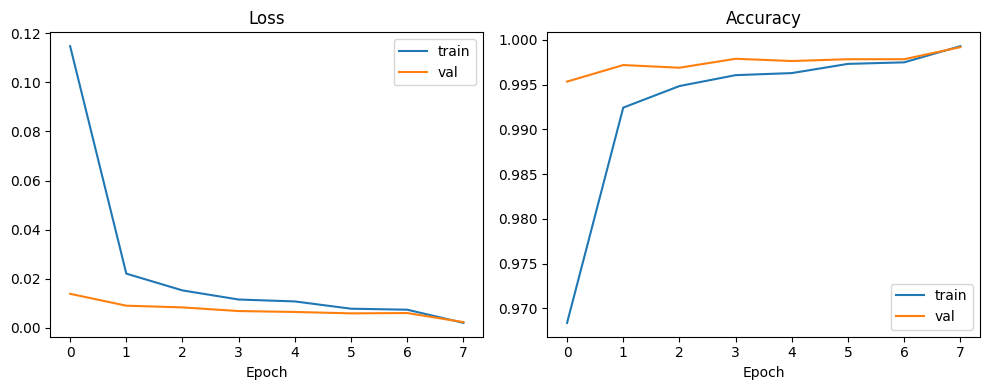

In [12]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("Loss"); plt.xlabel("Epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.legend()

plt.tight_layout()
plt.show()

**Evaluation on the held-out test set**

In [13]:
model.load_state_dict(torch.load("best_deepfake_detector.pth"))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of class index 1
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
print("Class indices:", idx_to_class)

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=[idx_to_class[0], idx_to_class[1]]))

print("Confusion matrix:")
print(confusion_matrix(all_labels, all_preds))

auc = roc_auc_score(all_labels, all_probs)
print(f"\nTest AUC: {auc:.4f}")

  0%|          | 0/625 [00:00<?, ?it/s]

Class indices: {0: 'fake', 1: 'real'}

Classification report:
              precision    recall  f1-score   support

        fake       1.00      1.00      1.00     10000
        real       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

Confusion matrix:
[[9995    5]
 [   3 9997]]

Test AUC: 1.0000


 **Inference: classify your own photo**

Two helper functions:
- `crop_face` — detects and crops the largest face in an arbitrary photo (recommended, since the training data is tightly-cropped faces — feeding it a full photo with background hurts accuracy).
- `predict_photo` — runs the crop + the model and shows the result.

In [14]:
import cv2

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def crop_face(image_path, margin=0.3):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    if len(faces) == 0:
        print("No face detected — using the full image instead.")
        return Image.open(image_path).convert("RGB")

    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])  # pick the largest detected face
    mx, my = int(w * margin), int(h * margin)
    x1, y1 = max(0, x - mx), max(0, y - my)
    x2, y2 = min(img.shape[1], x + w + mx), min(img.shape[0], y + h + my)

    cropped = img[y1:y2, x1:x2]
    cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    return Image.fromarray(cropped_rgb)


def predict_photo(image_path, auto_crop=True):
    image = crop_face(image_path) if auto_crop else Image.open(image_path).convert("RGB")
    input_tensor = eval_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = probs.argmax().item()

    label = idx_to_class[pred_idx]
    confidence = probs[pred_idx].item()

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {label.upper()}  ({confidence * 100:.1f}% confidence)")
    plt.show()

    print(f"This photo is predicted to be: {label.upper()} ({confidence * 100:.1f}% confidence)")
    return label, confidence

Saving Screenshot 2026-06-22 035722.png to Screenshot 2026-06-22 035722 (1).png


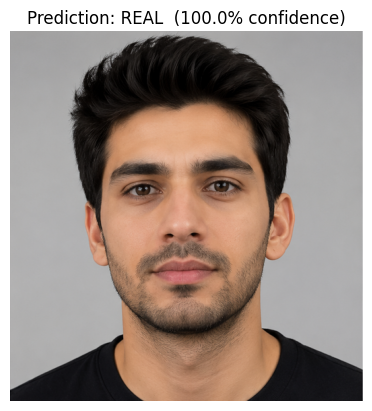

This photo is predicted to be: REAL (100.0% confidence)


('real', 1.0)

In [19]:
# ON COLAB: upload a photo from your computer and classify it
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

predict_photo(image_path)

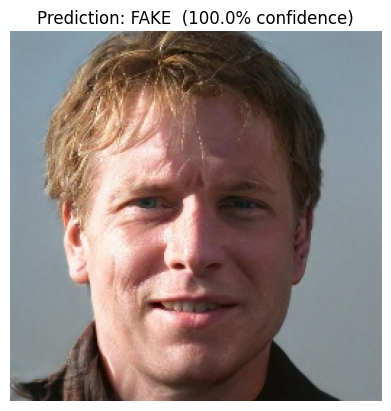

This photo is predicted to be: FAKE (100.0% confidence)


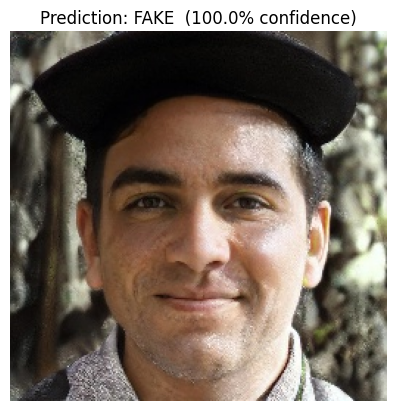

This photo is predicted to be: FAKE (100.0% confidence)


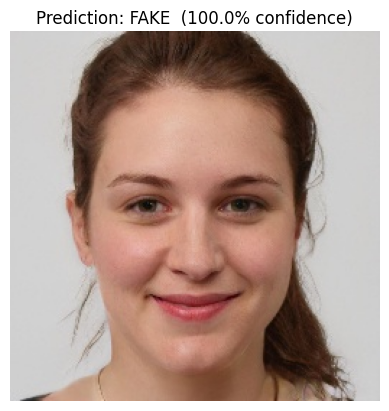

This photo is predicted to be: FAKE (100.0% confidence)


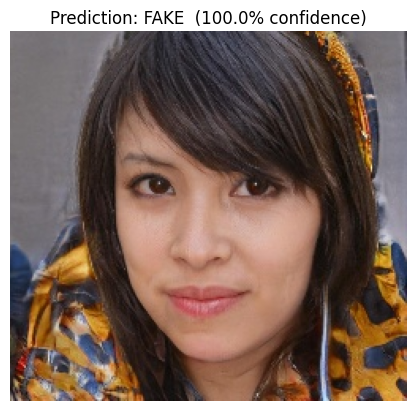

This photo is predicted to be: FAKE (100.0% confidence)


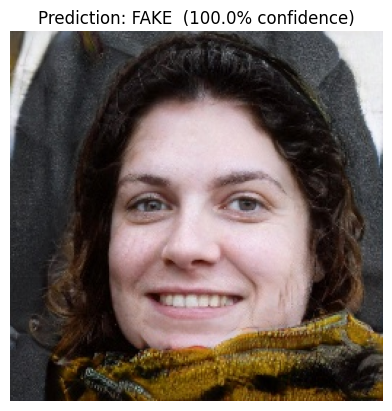

This photo is predicted to be: FAKE (100.0% confidence)


In [20]:
sample_dir = os.path.join(DATA_DIR, "test", "fake")
sample_files = os.listdir(sample_dir)[:5]

for fname in sample_files:
    predict_photo(os.path.join(sample_dir, fname))